In [3]:
#Importación de librerías
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

In [4]:
os.chdir(r'\Users\DAY\Desktop\DIPLOMADO_ANALISIS_DE_DATOS')
df = pd.read_csv("CC_GENERAL.csv")
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [6]:
#Limpieza de nulos
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())

In [7]:
#Como no hay fecha, se va a usar BALANCE como la variable principal de la serie
serie = df["BALANCE"].reset_index(drop=True)
serie.head()

0      40.900749
1    3202.467416
2    2495.148862
3    1666.670542
4     817.714335
Name: BALANCE, dtype: float64

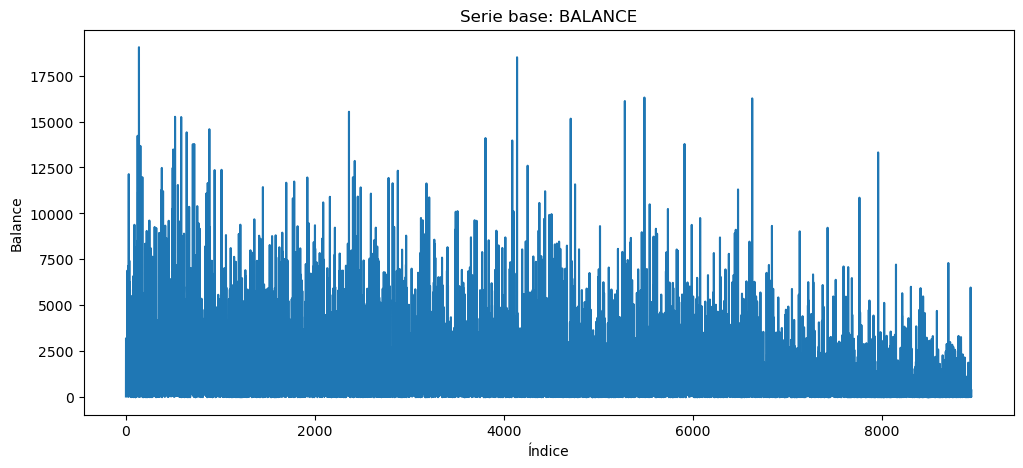

In [8]:
plt.figure(figsize=(12,5))
plt.plot(serie)
plt.title("Serie base: BALANCE")
plt.xlabel("Índice")
plt.ylabel("Balance")
plt.show()

In [9]:
#Reversión a la media 
np.random.seed(42)

x = serie.values
mu = np.mean(x)
theta = 0.15
sigma = np.std(x) * 0.1

mean_reversion = [x[0]]

for t in range(1, len(x)):
    prev = mean_reversion[-1]
    new_value = prev + theta * (mu - prev) + sigma * np.random.normal()
    mean_reversion.append(new_value)

mean_reversion = pd.Series(mean_reversion)

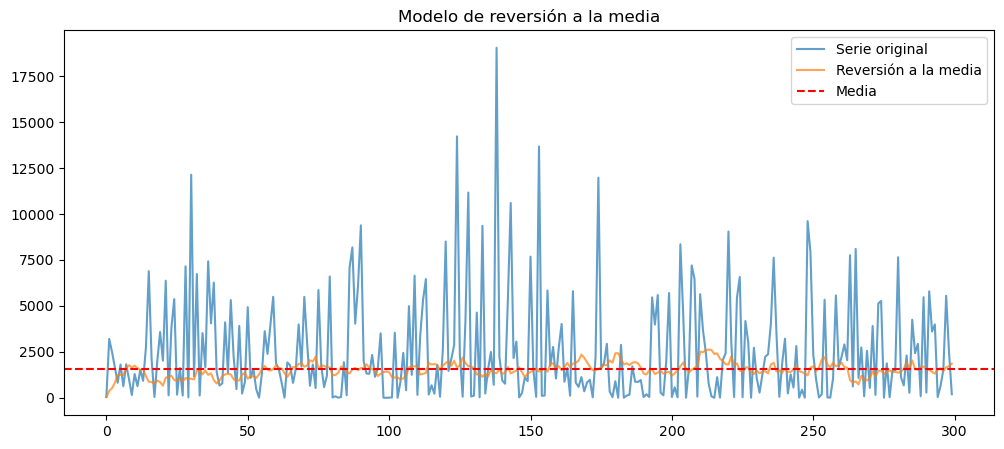

In [10]:
plt.figure(figsize=(12,5))
plt.plot(serie[:300], label="Serie original", alpha=0.7)
plt.plot(mean_reversion[:300], label="Reversión a la media", alpha=0.7)
plt.axhline(mu, color="red", linestyle="--", label="Media")
plt.title("Modelo de reversión a la media")
plt.legend()
plt.show()

In [11]:
#Movimiento Browniano
serie_gbm = serie.copy() + 1  # para evitar log(0)
log_returns = np.log(serie_gbm / serie_gbm.shift(1)).dropna()

In [12]:
#Estimación de parámetros
mu_gbm = log_returns.mean()
sigma_gbm = log_returns.std()

In [13]:
np.random.seed(42)

n = len(serie_gbm)
S0 = serie_gbm.iloc[0]
gbm = [S0]

for t in range(1, n):
    z = np.random.normal()
    St = gbm[-1] * np.exp((mu_gbm - 0.5 * sigma_gbm**2) + sigma_gbm * z)
    gbm.append(St)

gbm = pd.Series(gbm)

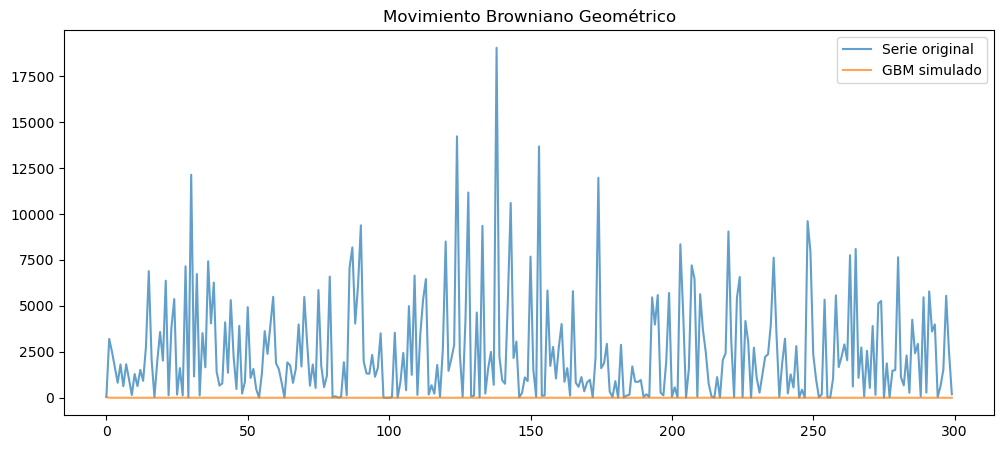

In [14]:
plt.figure(figsize=(12,5))
plt.plot(serie_gbm[:300].reset_index(drop=True), label="Serie original", alpha=0.7)
plt.plot(gbm[:300], label="GBM simulado", alpha=0.7)
plt.title("Movimiento Browniano Geométrico")
plt.legend()
plt.show()

In [15]:
#Modelo autoregresivo
train_size = int(len(serie) * 0.8)
train, test = serie[:train_size], serie[train_size:]

In [16]:
#Con AR(1)
model_ar = AutoReg(train, lags=1).fit()
print(model_ar.summary())

                            AutoReg Model Results                             
Dep. Variable:                BALANCE   No. Observations:                 7160
Model:                     AutoReg(1)   Log Likelihood              -65291.763
Method:               Conditional MLE   S.D. of innovations           2211.213
Date:                Tue, 17 Mar 2026   AIC                         130589.526
Time:                        19:01:10   BIC                         130610.154
Sample:                             1   HQIC                        130596.626
                                 7160                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1726.0737     33.391     51.693      0.000    1660.628    1791.519
BALANCE.L1     0.0187      0.012      1.579      0.114      -0.005       0.042
                                    Roots           

In [17]:
pred_ar = model_ar.predict(start=len(train), end=len(train)+len(test)-1)

In [18]:
rmse_ar = np.sqrt(mean_squared_error(test, pred_ar))
print("RMSE AR:", rmse_ar)

RMSE AR: 1512.2169155602367


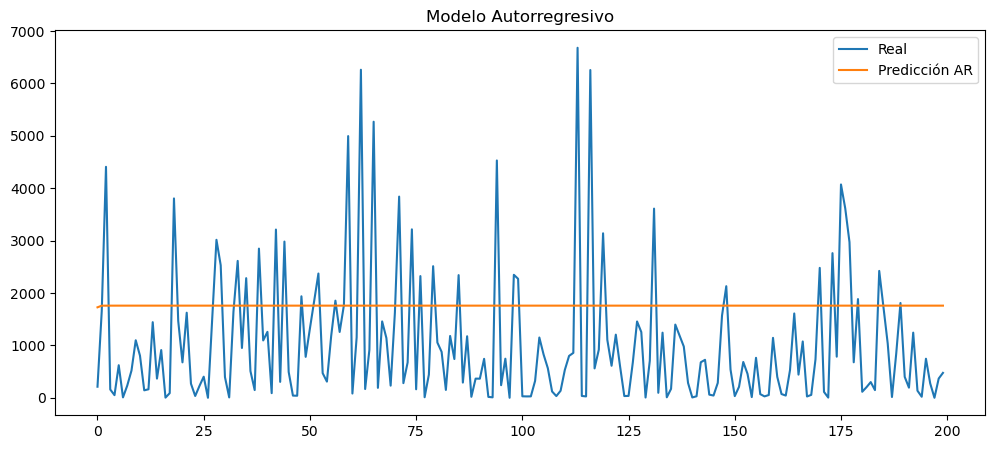

In [19]:
plt.figure(figsize=(12,5))
plt.plot(test.values[:200], label="Real")
plt.plot(pred_ar.values[:200], label="Predicción AR")
plt.title("Modelo Autorregresivo")
plt.legend()
plt.show()

In [20]:
#Modelo Moving Average
#MA(1)
model_ma = ARIMA(train, order=(0,0,1)).fit()
print(model_ma.summary())

                               SARIMAX Results                                
Dep. Variable:                BALANCE   No. Observations:                 7160
Model:                 ARIMA(0, 0, 1)   Log Likelihood              -65300.748
Date:                Tue, 17 Mar 2026   AIC                         130607.497
Time:                        19:02:02   BIC                         130628.125
Sample:                             0   HQIC                        130614.597
                               - 7160                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1758.6462     40.885     43.014      0.000    1678.512    1838.780
ma.L1          0.0177      0.012      1.458      0.145      -0.006       0.042
sigma2      4.891e+06   6.14e+04     79.652      0.0

In [21]:
pred_ma = model_ma.predict(start=len(train), end=len(train)+len(test)-1)

In [22]:
rmse_ma = np.sqrt(mean_squared_error(test, pred_ma))
print("RMSE MA:", rmse_ma)

RMSE MA: 1512.063871612767


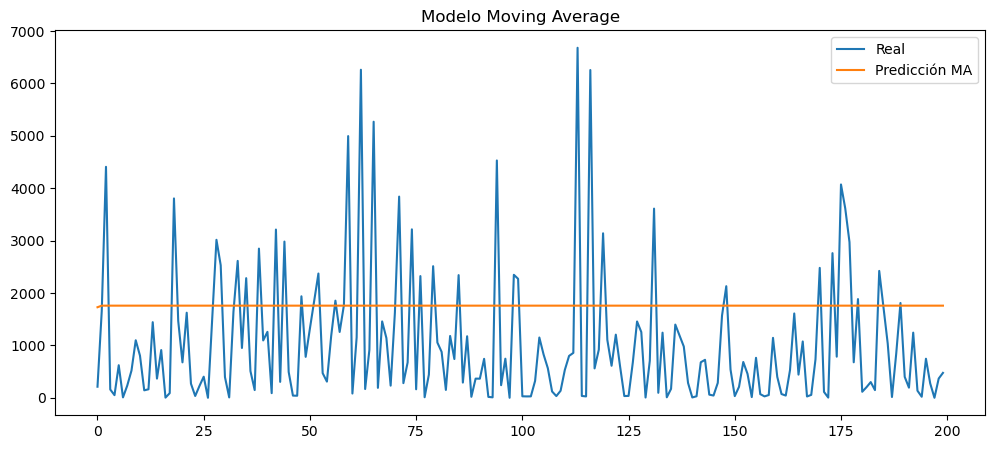

In [23]:
plt.figure(figsize=(12,5))
plt.plot(test.values[:200], label="Real")
plt.plot(pred_ma.values[:200], label="Predicción MA")
plt.title("Modelo Moving Average")
plt.legend()
plt.show()

In [24]:
#Comparando los modelos
resultados = pd.DataFrame({"Modelo": ["AR(1)", "MA(1)"],"RMSE": [rmse_ar, rmse_ma]})

print(resultados)

  Modelo         RMSE
0  AR(1)  1512.216916
1  MA(1)  1512.063872
